<a href="https://colab.research.google.com/github/ac-navalta/data-mining/blob/main/Philippine_Earthquake_Risk_Level_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Dataset Selection
This project utilizes the **Philippine Earthquakes 1900–2026 dataset (USGS/Kaggle)** to analyze the nation's seismic history. By examining variables such as magnitude, location, and depth, the study identifies high-risk clusters and trends. These insights are intended to strengthen disaster preparedness and regional risk mitigation.

In [ ]:
# Dataset Initialization

dataset = 'https://raw.githubusercontent.com/ac-navalta/data-mining/main/Philippine_Earthquakes_USGS.csv'
df = pd.read_csv(dataset)

df

,id,mag,place,time,updated,tz,url,detail,felt,cdi,...,nst,dmin,rms,gap,magType,type_property,title,longitude,latitude,depth
0,us7000rs17,4.40,"35 km W of Sangay, Philippines",2026-01-26 08:33:44.474,2026-01-26 12:30:30.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,25.0,1.947,0.66,136.0,mb,earthquake,"M 4.4 - 35 km W of Sangay, Philippines",123.7249,6.4342,14.819
1,us7000rrsh,4.90,"38 km S of Sarangani, Philippines",2026-01-24 18:45:54.402,2026-01-24 19:01:10.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,63.0,2.002,0.92,77.0,mb,earthquake,"M 4.9 - 38 km S of Sarangani, Philippines",125.4189,5.0607,180.096
2,us7000rrqv,4.30,"8 km E of Marihatag, Philippines",2026-01-24 08:26:02.342,2026-01-24 11:32:51.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,40.0,1.896,0.80,107.0,mb,earthquake,"M 4.3 - 8 km E of Marihatag, Philippines",126.3705,8.8077,75.390
3,us7000rrqm,4.50,"7 km NE of Sarangani, Philippines",2026-01-24 07:30:17.101,2026-01-24 07:53:25.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,40.0,1.604,0.94,86.0,mb,earthquake,"M 4.5 - 7 km NE of Sarangani, Philippines",125.5072,5.4571,199.646
4,us7000rr3q,4.70,"7 km NW of Bantogon, Philippines",2026-01-21 20:59:22.170,2026-01-22 17:34:20.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,45.0,12.425,0.65,87.0,mb,earthquake,"M 4.7 - 7 km NW of Bantogon, Philippines",123.9820,6.5810,9.895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26681,iscgemsup610548610,NaN,"21 km NE of Luklukan, Philippines",1905-07-28 06:22:43.160,2022-05-09 23:23:12.668,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,earthquake,"M ? - 21 km NE of Luklukan, Philippines",122.8280,14.4850,15.000
26682,iscgemsup610548608,6.06,"25 km SSE of Alburquerque, Philippines",1905-07-17 02:46:55.430,2022-05-09 23:23:06.117,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,NaN,NaN,NaN,NaN,mw,earthquake,"M 6.1 - 25 km SSE of Alburquerque, Philippines",124.0300,9.3860,35.000
26683,iscgem610548604,6.80,"61 km NW of Davila, Philippines",1905-06-01 02:23:32.750,2022-04-26 04:39:25.950,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,NaN,NaN,NaN,NaN,mw,earthquake,"M 6.8 - 61 km NW of Davila, Philippines",120.2030,18.8950,15.000
26684,cent19031228025600000,7.10,"Mindanao, Philippines",1903-12-28 10:56:00,2025-05-28 06:47:30.964,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,NaN,NaN,NaN,NaN,mw,earthquake,"M 7.1 - Mindanao, Philippines",127.0000,7.0000,NaN


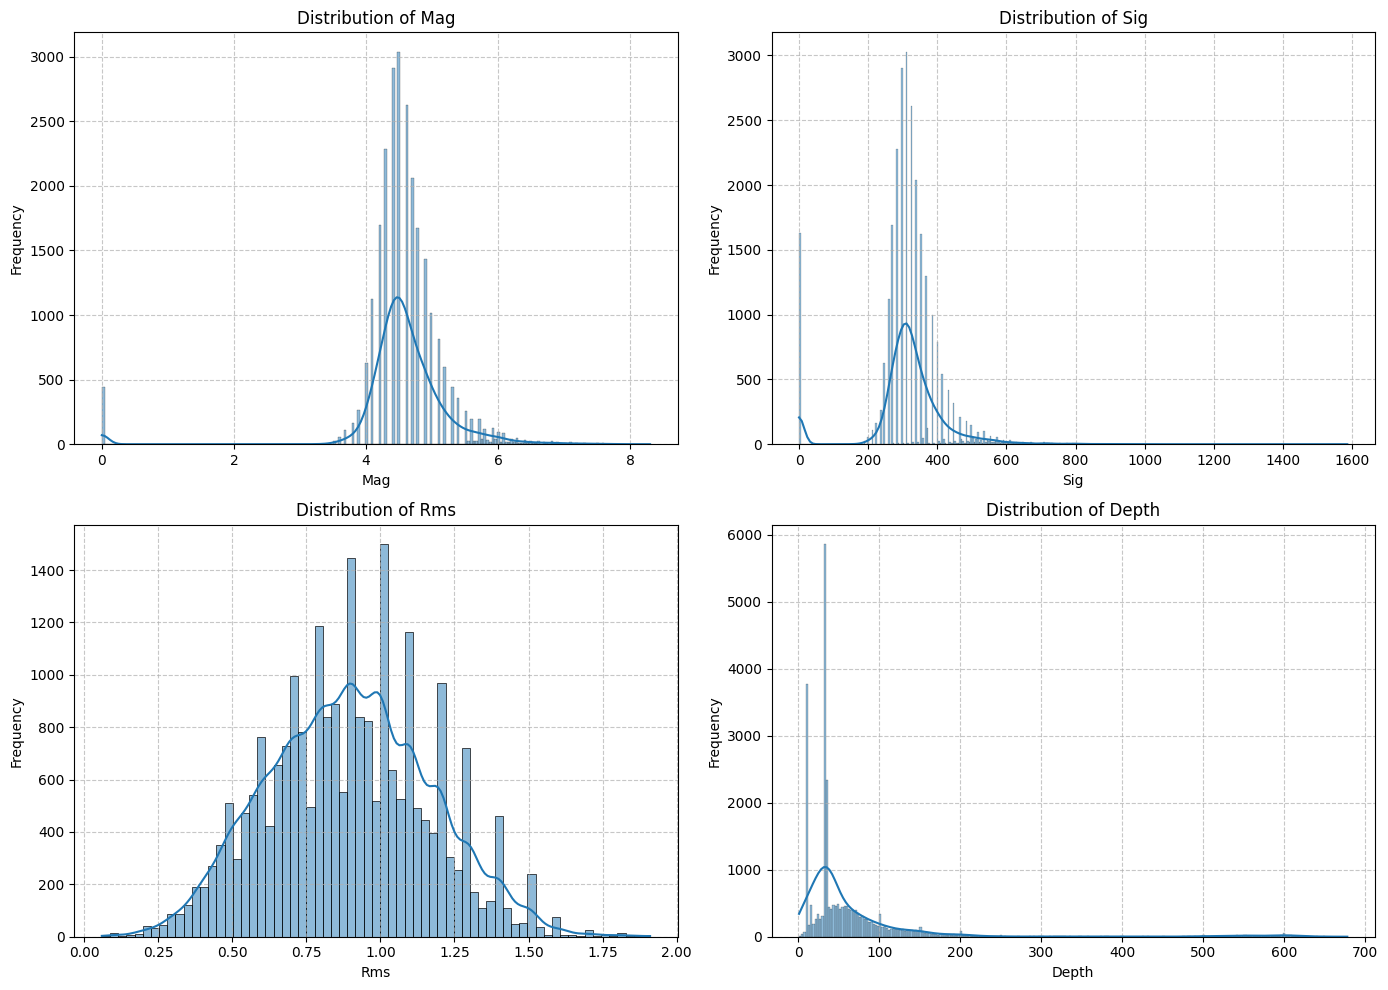

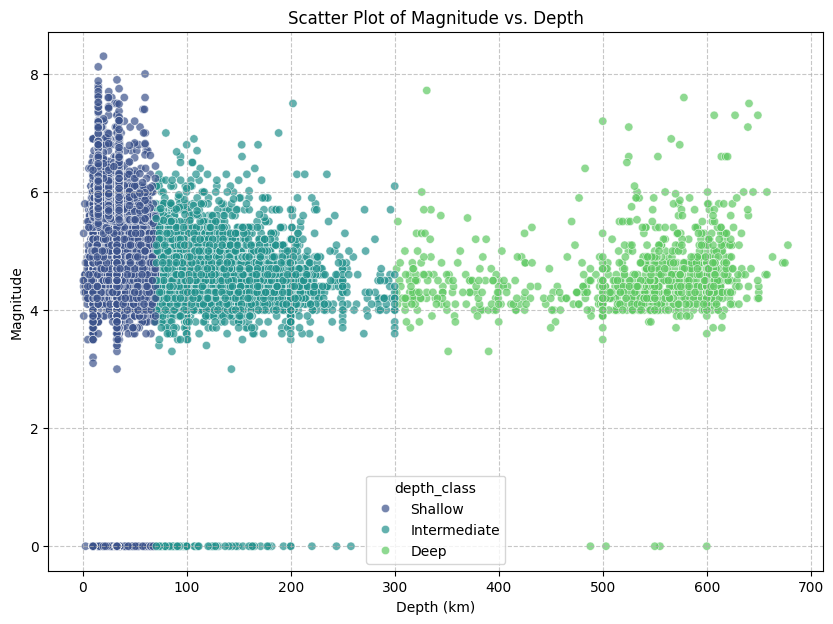

In [ ]:
# Exploratory Data Analysis

columns_to_plot = ['mag', 'sig', 'rms', 'depth']

# Histograms and distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Create the 'depth_class' column
def depth_class(d):
    if d <= 70:
        return "Shallow"
    elif d <= 300:
        return "Intermediate"
    else:
        return "Deep"

df["depth_class"] = df["depth"].apply(depth_class)

# Scatter plot: mag vs depth
plt.figure(figsize=(10, 7))
sns.scatterplot(x='depth', y='mag', data=df, hue='depth_class', palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Magnitude vs. Depth')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Dataset Preprocessing

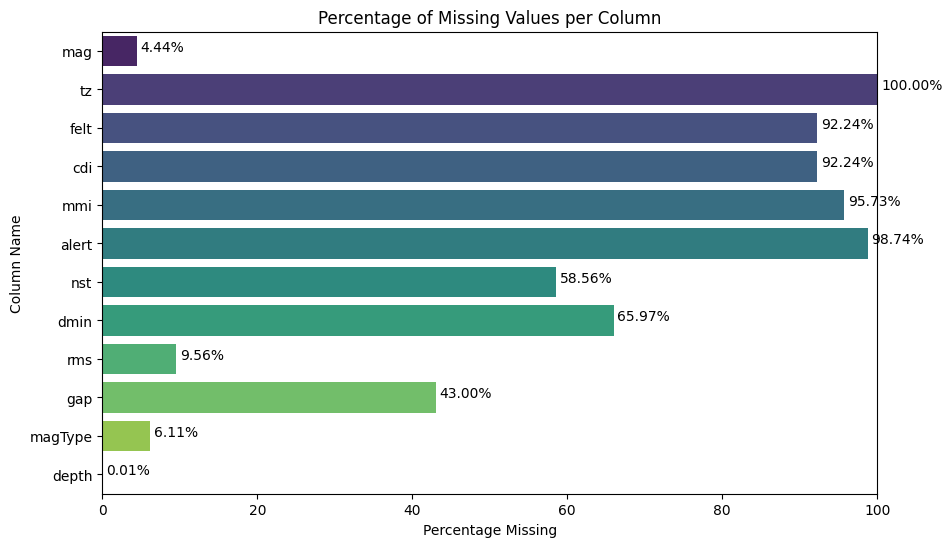

In [ ]:
# Handling Missing Values

# Caculate missing values
missing_values = df.isnull().sum()

# Filter out columns with no missing values
missing_values_exist = missing_values[missing_values > 0]

# Calculate the percentage of missing values
total_rows = len(df)
percentage_missing = (missing_values_exist / total_rows) * 100

# Create a DataFrame for plotting
percentage_missing_df = percentage_missing.reset_index()
percentage_missing_df.columns = ['Column', 'Percentage_Missing']

# Visualize the percentage of missing values
plt.figure(figsize=(10, 6))
sns.barplot(x='Percentage_Missing', y='Column', hue='Column', data=percentage_missing_df, palette='viridis', legend=False)
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Percentage Missing')
plt.ylabel('Column Name')
plt.xlim(0, 100) # Ensure x-axis goes from 0 to 100%
for index, row in percentage_missing_df.iterrows():
    plt.text(row['Percentage_Missing'] + 0.5, index, f"{row['Percentage_Missing']:.2f}%")
plt.show()

In [ ]:
# Data Cleaning
df = df.drop(columns=["tz", "felt", "cdi", "mmi", "alert", "nst", "dmin", "gap"])

# remove: rows with blank magnitude
df = df.dropna(subset=["mag"])

# remove: rows with 0.0 magnitude
df = df[df["mag"] != 0.0]

# remove: rows whose magType is not 'mb' and 'mw'
df = df[(df["magType"] == "mb") | (df["magType"] == "mw")]

# fill: rms (median)
df["rms"] = df["rms"].fillna(df["rms"].median())

# fill: depth (median)
df["depth"] = df["depth"].fillna(df["depth"].median())

# optional: reset index after filtering
df = df.reset_index(drop=True)

In [ ]:
# Data Transformation

# Convert: mb magType to mw
# Create a new column 'mag_converted' by first copying 'mag'
df['mag_converted'] = df['mag']

# Convert 'mb' magnitude to 'mw' magnitude in 'mag_converted' column
mb_mask = df["magType"] == "mb"
df.loc[mb_mask, "mag_converted"] = np.exp(0.741 + 0.210 * df.loc[mb_mask, "mag_converted"]) - 0.785

# Update 'magType' from 'mb' to 'mw' for converted magnitudes
df.loc[mb_mask, 'magType'] = 'mw'

# Normalize: depth, sig, rms; use Z-score standardization

z_cols = ["depth", "sig", "rms"]
z_scaler = StandardScaler()
df[['depth_z', 'sig_z', 'rms_z']] = z_scaler.fit_transform(df[z_cols])

# Normalize: longitude, latitude; use min-max scaling

mm_cols = ["longitude", "latitude"]
mm_scaler = MinMaxScaler()
df['longitude_mm'] = mm_scaler.fit_transform(df[['longitude']])
df['latitude_mm'] = mm_scaler.fit_transform(df[['latitude']])

In [ ]:
# Feature Engineering

# Depth, Depth Class, and Depth encoded
def depth_class(d):
    if d <= 70:
        return "Shallow"
    elif d <= 300:
        return "Intermediate"
    else:
        return "Deep"

df["depth_class"] = df["depth"].apply(depth_class)

depth_map = {
    "Deep": 0,
    "Intermediate": 1,
    "Shallow": 2
}

df["depth_encoded"] = df["depth_class"].map(depth_map)

# Magnitude, Magnitude Class, and Magnitude encoded
def mag_class(m):
    if m <= 3:
        return "Micro"
    elif m < 4:
        return "Minor"
    elif m < 5:
        return "Light"
    elif m < 6:
        return "Moderate"
    elif m < 7:
        return "Strong"
    elif m < 8:
        return "Major"
    else:
        return "Great"

df["mag_class"] = df["mag_converted"].apply(mag_class)

mag_map = {
    "Micro": 0,
    "Minor": 1,
    "Light": 2,
    "Moderate": 3,
    "Strong": 4,
    "Major": 5,
    "Great": 6
}

df["mag_encoded"] = df["mag_class"].map(mag_map)

# Risk Levels, and Risk Levels encoded
def assign_risk(row):
    mag = row["mag_class"]
    depth = row["depth_class"]

    if mag in ['Micro', 'Minor']:
        return "Low"

    if mag == 'Light':
        return "Moderate" if depth == "Shallow" else "Low"

    if mag == 'Moderate':
        if depth == "Shallow":
            return "High"
        elif depth == "Intermediate":
            return "Moderate"
        return "Low"

    if mag == 'Strong':
        if depth == "Shallow":
            return "Very High"
        elif depth == "Intermediate":
            return "High"
        return "Moderate"

    if mag == 'Major':
        return "Very High" if depth != "Deep" else "High"

    if mag == 'Great':
        return "Very High"

df['risk_level'] = df.apply(assign_risk, axis=1)

risk_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Very High": 3
}

df['risk_encoded'] = df['risk_level'].map(risk_map)

In [ ]:
# Drop metadata and identifiers
df = df.drop(columns=['id', 'place', 'time', 'updated', 'url', 'detail', 'status', 'net', 'code', 'ids', 'sources', 'types', 'title', 'type_property', 'magType'])

In [ ]:
# Keep transformed, normalized, and encoded numerical features
cleaned_dataset = df[['tsunami', 'sig_z', 'rms_z', 'longitude_mm', 'latitude_mm', 'mag_encoded', 'depth_encoded', 'risk_encoded']]

Optimal number of features: 3


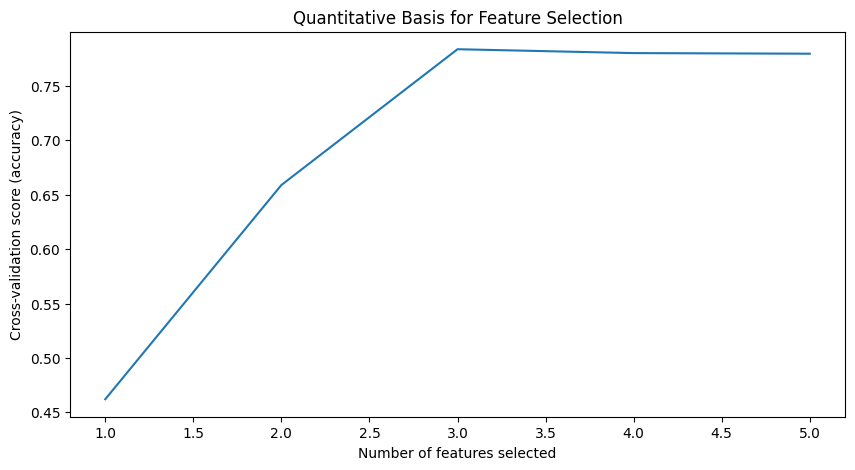

In [ ]:
# Feature Selection
X = cleaned_dataset.drop(columns=['mag_encoded', 'depth_encoded', 'risk_encoded']) # Do not include target variable and directly related features
y = cleaned_dataset['risk_encoded']

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Initialize the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Initialize RFECV
min_features_to_select = 1
rfecv = RFECV(estimator=rf, step=1, cv=StratifiedKFold(5), scoring='accuracy', min_features_to_select=1)
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")

# Plotting the results
plt.figure(figsize=(10, 5))
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (accuracy)")
plt.plot(range(min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + min_features_to_select),
         rfecv.cv_results_['mean_test_score'])
plt.title("Quantitative Basis for Feature Selection")
plt.show()

In [ ]:
# The 'support_' attribute tells us which features are selected
selected_features = X.columns[rfecv.support_]
print("Columns to keep:", list(selected_features))

# The 'ranking_' attribute tells us the priority of dropped columns
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Rank': rfecv.ranking_})
print(feature_ranking.sort_values(by='Rank'))

Columns to keep: ['sig_z', 'longitude_mm', 'latitude_mm']
        Feature  Rank
1         sig_z     1
3  longitude_mm     1
4   latitude_mm     1
2         rms_z     2
0       tsunami     3


# Model Training

In [ ]:
from sklearn.model_selection import train_test_split

# Choose features and labels
X = df[['longitude_mm', 'latitude_mm', 'tsunami', 'sig_z']]
y = df['risk_encoded']

splits = [0.5, 0.4, 0.3, 0.25, 0.2]

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for test_size in splits:
    train_p = int((1 - test_size) * 100)
    test_p = int(test_size * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    lr = LogisticRegression(max_iter=10000)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    print(f"\n--------------- {train_p}/{test_p} Split ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
    print(confusion_matrix(y_test, y_pred_lr))
    print(classification_report(y_test, y_pred_lr))


--------------- 50/50 Split ---------------
Accuracy: 0.6884
[[ 816 2139   39    0]
 [ 559 5980  288    0]
 [   0  548 1067   10]
 [   0    0   52  166]]
              precision    recall  f1-score   support

           0       0.59      0.27      0.37      2994
           1       0.69      0.88      0.77      6827
           2       0.74      0.66      0.69      1625
           3       0.94      0.76      0.84       218

    accuracy                           0.69     11664
   macro avg       0.74      0.64      0.67     11664
weighted avg       0.68      0.69      0.66     11664


--------------- 60/40 Split ---------------
Accuracy: 0.6895
[[ 652 1712   31    0]
 [ 449 4793  219    1]
 [   0  438  850   12]
 [   0    0   36  139]]
              precision    recall  f1-score   support

           0       0.59      0.27      0.37      2395
           1       0.69      0.88      0.77      5462
           2       0.75      0.65      0.70      1300
           3       0.91      0.79     

### K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for test_size in splits:
    train_p = int((1 - test_size) * 100)
    test_p = int(test_size * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    knn = KNeighborsClassifier()
    knn.fit(X_train, y_train)

    y_pred_knn = knn.predict(X_test)

    print(f"\n--------------- {train_p}/{test_p} Split ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
    print(confusion_matrix(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn))


--------------- 50/50 Split ---------------
Accuracy: 0.7881
[[1927 1038   28    1]
 [ 899 5658  264    6]
 [  28  154 1423   20]
 [   0    2   32  184]]
              precision    recall  f1-score   support

           0       0.68      0.64      0.66      2994
           1       0.83      0.83      0.83      6827
           2       0.81      0.88      0.84      1625
           3       0.87      0.84      0.86       218

    accuracy                           0.79     11664
   macro avg       0.80      0.80      0.80     11664
weighted avg       0.79      0.79      0.79     11664


--------------- 60/40 Split ---------------
Accuracy: 0.7944
[[1553  816   26    0]
 [ 677 4593  187    5]
 [  26  130 1118   26]
 [   0    3   23  149]]
              precision    recall  f1-score   support

           0       0.69      0.65      0.67      2395
           1       0.83      0.84      0.83      5462
           2       0.83      0.86      0.84      1300
           3       0.83      0.85     

### Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for test_size in splits:
    train_p = int((1 - test_size) * 100)
    test_p = int(test_size * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)

    print(f"\n--------------- {train_p}/{test_p} Split ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
    print(confusion_matrix(y_test, y_pred_dt))
    print(classification_report(y_test, y_pred_dt))


--------------- 50/50 Split ---------------
Accuracy: 0.7598
[[1874 1094   26    0]
 [1127 5456  237    7]
 [  15  217 1361   32]
 [   1    6   40  171]]
              precision    recall  f1-score   support

           0       0.62      0.63      0.62      2994
           1       0.81      0.80      0.80      6827
           2       0.82      0.84      0.83      1625
           3       0.81      0.78      0.80       218

    accuracy                           0.76     11664
   macro avg       0.76      0.76      0.76     11664
weighted avg       0.76      0.76      0.76     11664


--------------- 60/40 Split ---------------
Accuracy: 0.7577
[[1468  905   22    0]
 [ 901 4372  184    5]
 [  18  164 1092   26]
 [   1    5   30  139]]
              precision    recall  f1-score   support

           0       0.61      0.61      0.61      2395
           1       0.80      0.80      0.80      5462
           2       0.82      0.84      0.83      1300
           3       0.82      0.79     

### Support Vector Machine (SVM)

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for test_size in splits:
    train_p = int((1 - test_size) * 100)
    test_p = int(test_size * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    svm = SVC(random_state=42)
    svm.fit(X_train, y_train)

    y_pred_svm = svm.predict(X_test)

    print(f"\n--------------- {train_p}/{test_p} Split ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
    print(confusion_matrix(y_test, y_pred_svm))
    print(classification_report(y_test, y_pred_svm))


--------------- 50/50 Split ---------------
Accuracy: 0.7275
[[ 451 2471   72    0]
 [  85 6247  495    0]
 [   0    0 1614   11]
 [   0    0   45  173]]
              precision    recall  f1-score   support

           0       0.84      0.15      0.26      2994
           1       0.72      0.92      0.80      6827
           2       0.73      0.99      0.84      1625
           3       0.94      0.79      0.86       218

    accuracy                           0.73     11664
   macro avg       0.81      0.71      0.69     11664
weighted avg       0.75      0.73      0.67     11664


--------------- 60/40 Split ---------------
Accuracy: 0.7292
[[ 389 1945   61    0]
 [  89 4988  384    1]
 [   0    0 1288   12]
 [   0    0   35  140]]
              precision    recall  f1-score   support

           0       0.81      0.16      0.27      2395
           1       0.72      0.91      0.80      5462
           2       0.73      0.99      0.84      1300
           3       0.92      0.80     

### Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for test_size in splits:
    train_p = int((1 - test_size) * 100)
    test_p = int(test_size * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)

    print(f"\n--------------- {train_p}/{test_p} Split ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
    print(confusion_matrix(y_test, y_pred_rf))
    print(classification_report(y_test, y_pred_rf))


--------------- 50/50 Split ---------------
Accuracy: 0.8132
[[1976  992   26    0]
 [ 754 5823  246    4]
 [   9  101 1500   15]
 [   1    1   30  186]]
              precision    recall  f1-score   support

           0       0.72      0.66      0.69      2994
           1       0.84      0.85      0.85      6827
           2       0.83      0.92      0.88      1625
           3       0.91      0.85      0.88       218

    accuracy                           0.81     11664
   macro avg       0.83      0.82      0.82     11664
weighted avg       0.81      0.81      0.81     11664


--------------- 60/40 Split ---------------
Accuracy: 0.8175
[[1559  813   23    0]
 [ 568 4715  175    4]
 [   5   75 1204   16]
 [   1    1   22  151]]
              precision    recall  f1-score   support

           0       0.73      0.65      0.69      2395
           1       0.84      0.86      0.85      5462
           2       0.85      0.93      0.88      1300
           3       0.88      0.86     

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

results_summary = {
    'Split': [],
    'Logistic Regression_Accuracy': [],
    'Logistic Regression_Precision': [],
    'Logistic Regression_Recall': [],
    'Logistic Regression_F1-Score': [],
    'KNN_Accuracy': [],
    'KNN_Precision': [],
    'KNN_Recall': [],
    'KNN_F1-Score': [],
    'Decision Tree_Accuracy': [],
    'Decision Tree_Precision': [],
    'Decision Tree_Recall': [],
    'Decision Tree_F1-Score': [],
    'SVM_Accuracy': [],
    'SVM_Precision': [],
    'SVM_Recall': [],
    'SVM_F1-Score': [],
    'Random Forest_Accuracy': [],
    'Random Forest_Precision': [],
    'Random Forest_Recall': [],
    'Random Forest_F1-Score': []
}

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Logistic Regression
    lr_model = LogisticRegression(max_iter=10000)
    lr_model.fit(X_train, y_train)
    lr_y_pred = lr_model.predict(X_test)
    lr_accuracy = accuracy_score(y_test, lr_y_pred)
    lr_report = classification_report(y_test, lr_y_pred, output_dict=True)

    # K-Nearest Neighbors (KNN)
    knn_model = KNeighborsClassifier()
    knn_model.fit(X_train, y_train)
    knn_y_pred = knn_model.predict(X_test)
    knn_accuracy = accuracy_score(y_test, knn_y_pred)
    knn_report = classification_report(y_test, knn_y_pred, output_dict=True)

    # Decision Trees
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)
    dt_y_pred = dt_model.predict(X_test)
    dt_accuracy = accuracy_score(y_test, dt_y_pred)
    dt_report = classification_report(y_test, dt_y_pred, output_dict=True)

    # Support Vector Machine (SVM) - Requires scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    svm_model = SVC(random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    svm_y_pred = svm_model.predict(X_test_scaled)
    svm_accuracy = accuracy_score(y_test, svm_y_pred)
    svm_report = classification_report(y_test, svm_y_pred, output_dict=True)

    # Random Forest
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    rf_y_pred = rf_model.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_y_pred)
    rf_report = classification_report(y_test, rf_y_pred, output_dict=True)

    results_summary['Split'].append(f'{int((1-test_size)*100)}/{int(test_size*100)}')

    results_summary['Logistic Regression_Accuracy'].append(f'{lr_accuracy:.4f}')
    results_summary['Logistic Regression_Precision'].append(f'{lr_report["weighted avg"]["precision"]:.4f}')
    results_summary['Logistic Regression_Recall'].append(f'{lr_report["weighted avg"]["recall"]:.4f}')
    results_summary['Logistic Regression_F1-Score'].append(f'{lr_report["weighted avg"]["f1-score"]:.4f}')

    results_summary['KNN_Accuracy'].append(f'{knn_accuracy:.4f}')
    results_summary['KNN_Precision'].append(f'{knn_report["weighted avg"]["precision"]:.4f}')
    results_summary['KNN_Recall'].append(f'{knn_report["weighted avg"]["recall"]:.4f}')
    results_summary['KNN_F1-Score'].append(f'{knn_report["weighted avg"]["f1-score"]:.4f}')

    results_summary['Decision Tree_Accuracy'].append(f'{dt_accuracy:.4f}')
    results_summary['Decision Tree_Precision'].append(f'{dt_report["weighted avg"]["precision"]:.4f}')
    results_summary['Decision Tree_Recall'].append(f'{dt_report["weighted avg"]["recall"]:.4f}')
    results_summary['Decision Tree_F1-Score'].append(f'{dt_report["weighted avg"]["f1-score"]:.4f}')

    results_summary['SVM_Accuracy'].append(f'{svm_accuracy:.4f}')
    results_summary['SVM_Precision'].append(f'{svm_report["weighted avg"]["precision"]:.4f}')
    results_summary['SVM_Recall'].append(f'{svm_report["weighted avg"]["recall"]:.4f}')
    results_summary['SVM_F1-Score'].append(f'{svm_report["weighted avg"]["f1-score"]:.4f}')

    results_summary['Random Forest_Accuracy'].append(f'{rf_accuracy:.4f}')
    results_summary['Random Forest_Precision'].append(f'{rf_report["weighted avg"]["precision"]:.4f}')
    results_summary['Random Forest_Recall'].append(f'{rf_report["weighted avg"]["recall"]:.4f}')
    results_summary['Random Forest_F1-Score'].append(f'{rf_report["weighted avg"]["f1-score"]:.4f}')

summary_df = pd.DataFrame(results_summary)

print("\n--- Accuracy Scores ---")
accuracy_cols = ['Split'] + [col for col in summary_df.columns if 'Accuracy' in col]
accuracy_df = summary_df[accuracy_cols]
display(accuracy_df)

print("\n--- Precision Scores (Weighted Average) ---")
precision_cols = ['Split'] + [col for col in summary_df.columns if 'Precision' in col]
precision_df = summary_df[precision_cols]
display(precision_df)

print("\n--- Recall Scores (Weighted Average) ---")
recall_cols = ['Split'] + [col for col in summary_df.columns if 'Recall' in col]
recall_df = summary_df[recall_cols]
display(recall_df)

print("\n--- F1-Score (Weighted Average) ---")
f1_cols = ['Split'] + [col for col in summary_df.columns if 'F1-Score' in col]
f1_df = summary_df[f1_cols]
display(f1_df)



--- Accuracy Scores ---


,Split,Logistic Regression_Accuracy,KNN_Accuracy,Decision Tree_Accuracy,SVM_Accuracy,Random Forest_Accuracy
0,50/50,0.6884,0.7881,0.7598,0.7467,0.8132
1,60/40,0.6895,0.7944,0.7577,0.7520,0.8175
2,70/30,0.6881,0.8021,0.7638,0.7523,0.8158
3,75/25,0.6908,0.8013,0.7589,0.7551,0.8138
4,80/20,0.6869,0.8039,0.7615,0.7529,0.8157



--- Precision Scores (Weighted Average) ---


,Split,Logistic Regression_Precision,KNN_Precision,Decision Tree_Precision,SVM_Precision,Random Forest_Precision
0,50/50,0.6766,0.7864,0.7601,0.7445,0.8108
1,60/40,0.6774,0.7923,0.7575,0.7499,0.8144
2,70/30,0.6751,0.7993,0.7636,0.7513,0.8131
3,75/25,0.6779,0.7986,0.7590,0.7530,0.8112
4,80/20,0.6733,0.8015,0.7620,0.7497,0.8131



--- Recall Scores (Weighted Average) ---


,Split,Logistic Regression_Recall,KNN_Recall,Decision Tree_Recall,SVM_Recall,Random Forest_Recall
0,50/50,0.6884,0.7881,0.7598,0.7467,0.8132
1,60/40,0.6895,0.7944,0.7577,0.7520,0.8175
2,70/30,0.6881,0.8021,0.7638,0.7523,0.8158
3,75/25,0.6908,0.8013,0.7589,0.7551,0.8138
4,80/20,0.6869,0.8039,0.7615,0.7529,0.8157



--- F1-Score (Weighted Average) ---


,Split,Logistic Regression_F1-Score,KNN_F1-Score,Decision Tree_F1-Score,SVM_F1-Score,Random Forest_F1-Score
0,50/50,0.6602,0.7870,0.7599,0.7198,0.8113
1,60/40,0.6612,0.7931,0.7576,0.7279,0.8150
2,70/30,0.6605,0.8002,0.7637,0.7265,0.8136
3,75/25,0.6629,0.7995,0.7589,0.7318,0.8118
4,80/20,0.6588,0.8023,0.7617,0.7303,0.8137


## Hyperparameter Tuning
Based from the baseline results, Random Forest with a 60-40 split aquired the highest overall Accuracy, as well as highest Recall, Precision, and F1 Score across the board. Given this, the Random Forest model will undergo hyperparameter tuning using cross-validation to further improve its performance and ensure more reliable results.

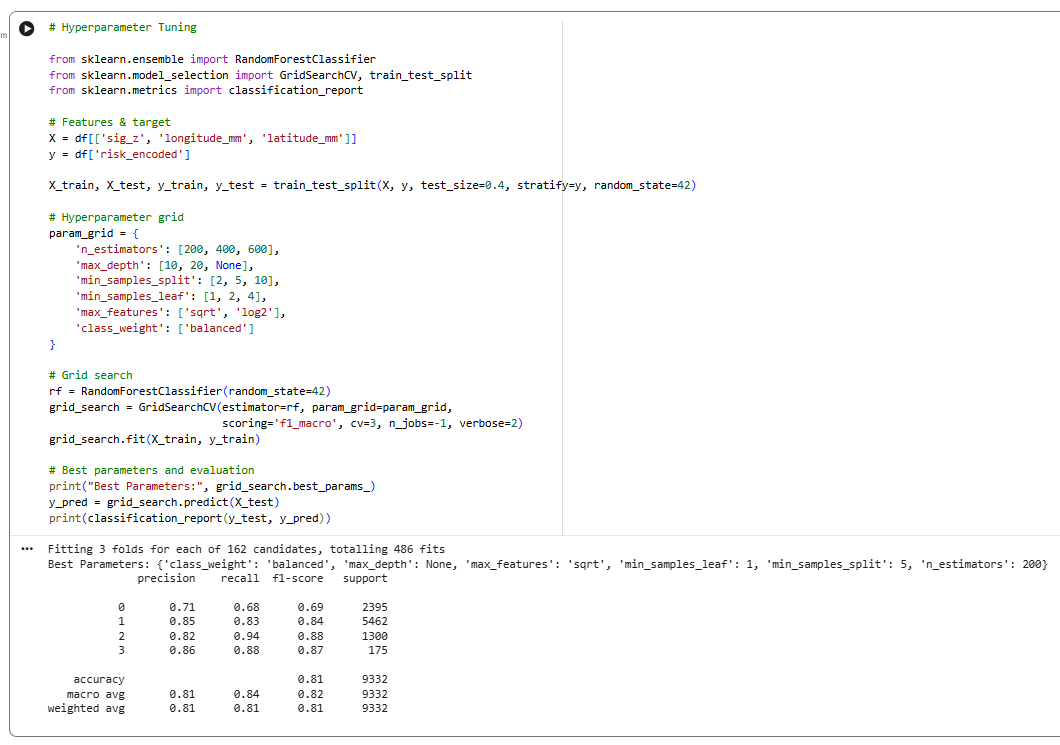

In [20]:
# Random Forest with hyperparameter-tuned settings

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

rf = RandomForestClassifier(class_weight='balanced',
                            max_depth=None,
                            max_features='sqrt',
                            min_samples_leaf=1,
                            min_samples_split=5,
                            n_estimators=200,
                            random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"\n--------------- Hyperparameter Tuned Random Forest ---------------")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


--------------- Hyperparameter Tuned Random Forest ---------------
Accuracy: 0.8165
[[1658  713   24    0]
 [ 651 4587  218    6]
 [   6   52 1220   22]
 [   1    0   19  155]]
              precision    recall  f1-score   support

           0       0.72      0.69      0.70      2395
           1       0.86      0.84      0.85      5462
           2       0.82      0.94      0.88      1300
           3       0.85      0.89      0.87       175

    accuracy                           0.82      9332
   macro avg       0.81      0.84      0.82      9332
weighted avg       0.82      0.82      0.82      9332

